# Experiment 1 - COMPAS Tabular Data XAI Disagreement

**Setup.** ProPublica-filtered COMPAS (6,172 records, 7 features). Two models matching Krishna et al. [1]: logistic regression (acc. 0.75) and a 50–100–50 ReLU NN (acc. 0.75). LIME and KernelSHAP run on every test sample (n = 1,235); four top-k disagreement metrics at k = 5: feature (FA), rank (RA), sign (SA), signed-rank (SRA) agreement. Subgroup means compared with two-sided Mann–Whitney U.

# Imports

In [1]:
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from lime.lime_tabular import LimeTabularExplainer
import shap

import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import mannwhitneyu

import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print('Ready')

Using device: cuda
GPU: NVIDIA H200
Ready


# Data cleaning (ProPublica methodology)

Clean the data following the filtering criteria from [ProPublica's COMPAS analysis](https://github.com/propublica/compas-analysis):

1. **±30 day screening filter** — if the charge date and arrest date are more than 30 days apart, the data likely matched the wrong offense
2. **is_recid ≠ -1** — drops cases where no COMPAS record could be found
3. **c_charge_degree ≠ 'O'** — removes ordinary traffic offenses (no jail time)
4. **score_text ≠ 'N/A'** — drops rows with no COMPAS score assigned
5. **Feature selection** — keeps the 7 features used by Krishna et al. (2022): age, sex, race, juvenile felony/misdemeanor/other counts, and priors count
6. **Binarize target** — converts COMPAS risk score into binary (Low = 0, Medium/High = 1)
7. **Drop NaN** — removes any remaining rows with missing values

All races are kept for model training to match Krishna et al.'s setup. The demographic split (African-American vs Caucasian) is applied later when comparing SHAP vs LIME disagreement metrics — that comparison is our original extension of their work.

In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw = pd.read_csv(url)
print(f"Raw rows: {len(raw)}")

Raw rows: 7214


In [3]:
df = raw[
    (raw['days_b_screening_arrest'] <= 30) &
    (raw['days_b_screening_arrest'] >= -30) &
    (raw['is_recid'] != -1) &
    (raw['c_charge_degree'] != 'O') &
    (raw['score_text'] != 'N/A')
].copy()
print(f"After ProPublica filters: {len(df)}")

After ProPublica filters: 6172


In [4]:
features = ['age', 'sex', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count']
df['target'] = (df['score_text'] != 'Low').astype(int)
df = df[features + ['target']].dropna()
print(f"Final rows: {len(df)}")

Final rows: 6172


In [5]:
print(f"\nRace distribution:\n{df['race'].value_counts()}")
print(f"\nTarget distribution:\n{df['target'].value_counts()}")
print(f"\nSex distribution:\n{df['sex'].value_counts()}")


Race distribution:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

Target distribution:
target
0    3421
1    2751
Name: count, dtype: int64

Sex distribution:
sex
Male      4997
Female    1175
Name: count, dtype: int64


In [6]:
df

,age,sex,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,target
0,69,Male,Other,0,0,0,0,0
1,34,Male,African-American,0,0,0,0,0
2,24,Male,African-American,0,0,1,4,0
5,44,Male,Other,0,0,0,0,0
6,41,Male,Caucasian,0,0,0,14,1
...,...,...,...,...,...,...,...,...
7209,23,Male,African-American,0,0,0,0,1
7210,23,Male,African-American,0,0,0,0,0
7211,57,Male,Other,0,0,0,0,0
7212,33,Female,African-American,0,0,0,3,0


# Encode categorical features
Label encode `sex` and `race` to convert string values to integers. We use label encoding instead of one-hot encoding to keep the feature count at 7.

In [7]:
le_sex = LabelEncoder()
le_race = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex'])
df['race'] = le_race.fit_transform(df['race'])

print(f"Sex mapping: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")
print(f"Race mapping: {dict(zip(le_race.classes_, le_race.transform(le_race.classes_)))}")
df.head()

Sex mapping: {'Female': 0, 'Male': 1}
Race mapping: {'African-American': 0, 'Asian': 1, 'Caucasian': 2, 'Hispanic': 3, 'Native American': 4, 'Other': 5}


,age,sex,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,target
0,69,1,5,0,0,0,0,0
1,34,1,0,0,0,0,0,0
2,24,1,0,0,0,1,4,0
5,44,1,5,0,0,0,0,0
6,41,1,2,0,0,0,14,1


# Train/test split
Split the data 80/20.

In [8]:
X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
len(X_train)

4937

# Logistic regression
Train a logistic regression model as the first of two models. Krishna et al. reported 0.75 test accuracy on COMPAS for this model.

In [10]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.7457

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       686
           1       0.73      0.68      0.70       549

    accuracy                           0.75      1235
   macro avg       0.74      0.74      0.74      1235
weighted avg       0.74      0.75      0.74      1235



# Neural network
3 hidden layers (50, 100, 50 neurons) with ReLU activation. They reported 0.73 test accuracy on COMPAS.

In [ ]:
class COMPASNet(nn.Module):
    def __init__(self, input_dim=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 2)
        )

    def forward(self, x):
        return self.net(x)
model_nn = COMPASNet(input_dim=7).to(device)
model_nn

COMPASNet(
  (net): Sequential(
    (0): Linear(in_features=7, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=50, bias=True)
    (5): ReLU()
    (6): Linear(in_features=50, out_features=2, bias=True)
  )
)

### Convert data to tensors

In [12]:
X_train_tensor = torch.FloatTensor(X_train.values).to(device)
y_train_tensor = torch.LongTensor(y_train.values).to(device)
X_test_tensor = torch.FloatTensor(X_test.values).to(device)
y_test_tensor = torch.LongTensor(y_test.values).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

### Train the neural network
Train for 50 epochs using Adam optimizer (lr=1e-3) and CrossEntropyLoss.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_nn.parameters(), lr=1e-3)

num_epochs = 50
train_losses = []
train_accs = []

for epoch in range(num_epochs):
    model_nn.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model_nn(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f} Train Acc: {epoch_acc:.4f}")

Epoch [10/50] Loss: 0.5104 Train Acc: 0.7375
Epoch [20/50] Loss: 0.5025 Train Acc: 0.7513
Epoch [30/50] Loss: 0.4965 Train Acc: 0.7521
Epoch [40/50] Loss: 0.4976 Train Acc: 0.7557
Epoch [50/50] Loss: 0.4899 Train Acc: 0.7543


### Evaluate the neural network

In [14]:
model_nn.eval()

with torch.no_grad():
    outputs = model_nn(X_test_tensor)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y_test_tensor).sum().item() / len(y_test_tensor)

print(f"\nNeural Network Test Accuracy: {accuracy:.4f}")
print(f"\n{classification_report(y_test, predicted.cpu().numpy())}")


Neural Network Test Accuracy: 0.7514

              precision    recall  f1-score   support

           0       0.82      0.71      0.76       686
           1       0.69      0.81      0.74       549

    accuracy                           0.75      1235
   macro avg       0.75      0.76      0.75      1235
weighted avg       0.76      0.75      0.75      1235



### Training curves

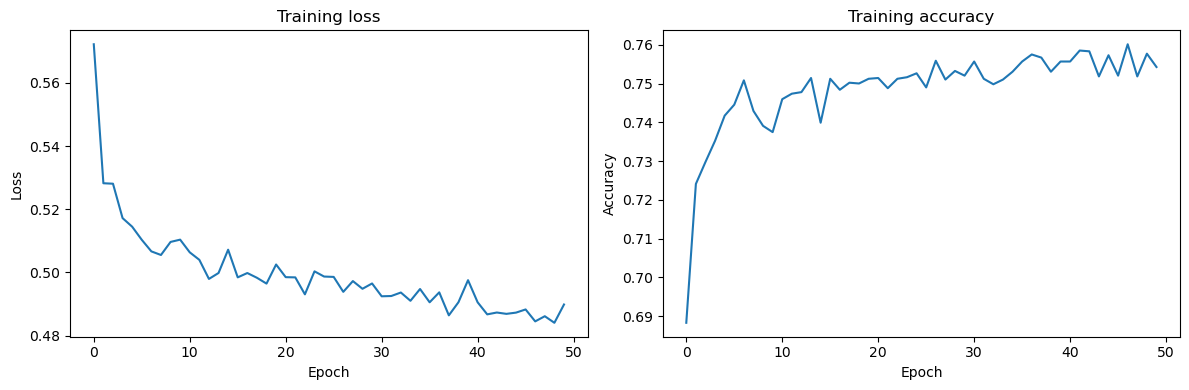

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training loss')

ax2.plot(train_accs)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training accuracy')

plt.tight_layout()
plt.show()

# LIME and SHAP for LR

### Set up 

In [16]:
explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=features,
    class_names=['Low Risk', 'High Risk'],
    mode='classification',
    random_state=42
)

background = shap.sample(X_train, 100, random_state=42)
explainer_shap_lr = shap.KernelExplainer(model_lr.predict_proba, background)

n_test = len(X_test)
lime_explanations = np.zeros((n_test, 7))

print("Running LIME...")
for i in tqdm(range(n_test)):
    exp = explainer_lime.explain_instance(
        X_test.values[i],
        model_lr.predict_proba,
        num_features=7
    )
    lime_dict = dict(exp.as_list())
    for j, f in enumerate(features):
        match = [v for k, v in lime_dict.items() if f in k]
        lime_explanations[i, j] = match[0] if match else 0

print("\nRunning KernelSHAP...")
shap_values_all = explainer_shap_lr.shap_values(X_test.values)
shap_explanations = shap_values_all[:, :, 1]

print(f"\nLIME explanations shape: {lime_explanations.shape}")
print(f"SHAP explanations shape: {shap_explanations.shape}")

Running LIME...


100%|██████████| 1235/1235 [00:10<00:00, 122.96it/s]


Running KernelSHAP...


  0%|          | 0/1235 [00:00<?, ?it/s]


LIME explanations shape: (1235, 7)
SHAP explanations shape: (1235, 7)


### Run LIME and KernelSHAP to full test set (without absolute to show Direction)

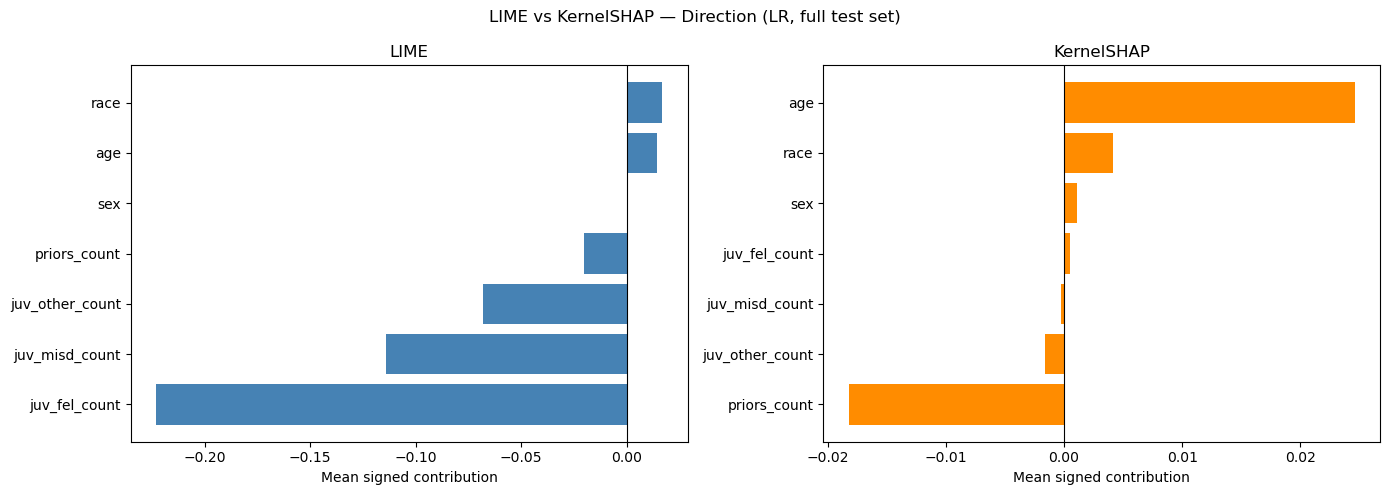

In [17]:
lime_signed = np.mean(lime_explanations, axis=0)
shap_signed = np.mean(shap_explanations, axis=0)
lime_signed_order = np.argsort(lime_signed)
shap_signed_order = np.argsort(shap_signed)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(range(7), lime_signed[lime_signed_order], color='steelblue')
ax1.set_yticks(range(7))
ax1.set_yticklabels(np.array(features)[lime_signed_order])
ax1.set_xlabel('Mean signed contribution')
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('LIME')

ax2.barh(range(7), shap_signed[shap_signed_order], color='darkorange')
ax2.set_yticks(range(7))
ax2.set_yticklabels(np.array(features)[shap_signed_order])
ax2.set_xlabel('Mean signed contribution')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('KernelSHAP')

plt.suptitle('LIME vs KernelSHAP — Direction (LR, full test set)')
plt.tight_layout()
plt.show()

### Run LIME and KernelSHAP to full test set (with absolute to show magnitude)

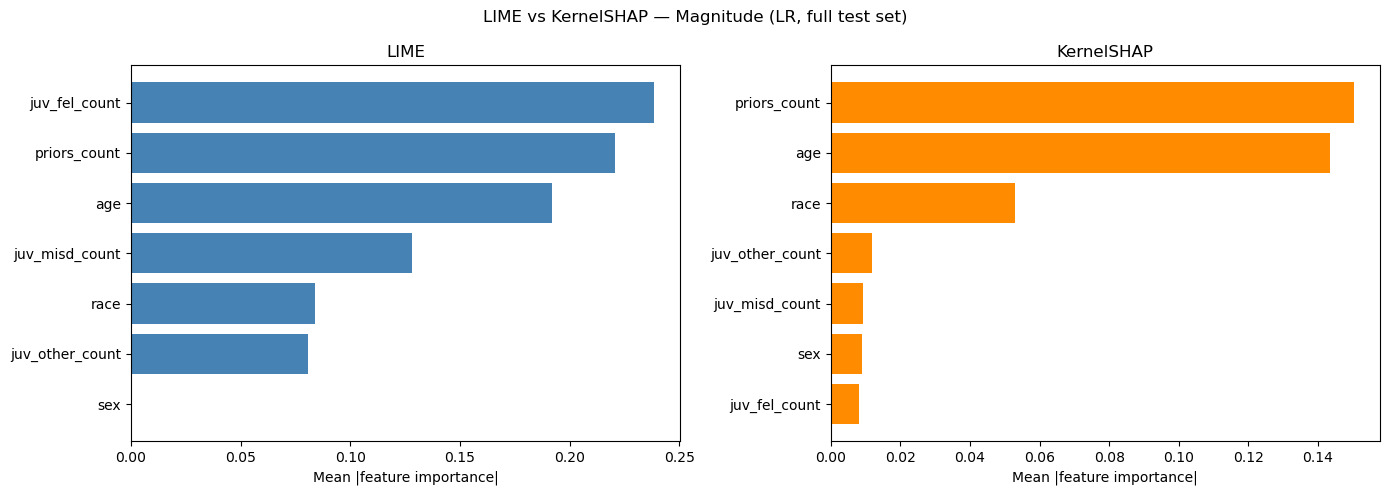

In [18]:
lime_abs = np.mean(np.abs(lime_explanations), axis=0)
shap_abs = np.mean(np.abs(shap_explanations), axis=0)
lime_abs_order = np.argsort(lime_abs)
shap_abs_order = np.argsort(shap_abs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(range(7), lime_abs[lime_abs_order], color='steelblue')
ax1.set_yticks(range(7))
ax1.set_yticklabels(np.array(features)[lime_abs_order])
ax1.set_xlabel('Mean |feature importance|')
ax1.set_title('LIME')

ax2.barh(range(7), shap_abs[shap_abs_order], color='darkorange')
ax2.set_yticks(range(7))
ax2.set_yticklabels(np.array(features)[shap_abs_order])
ax2.set_xlabel('Mean |feature importance|')
ax2.set_title('KernelSHAP')

plt.suptitle('LIME vs KernelSHAP — Magnitude (LR, full test set)')
plt.tight_layout()
plt.show()

# LIME and SHAP for NN

### Setup

In [19]:
def nn_predict_proba(X):
    model_nn.eval()
    with torch.no_grad():
        tensor = torch.FloatTensor(X).to(device)
        outputs = model_nn(tensor)
        probs = torch.softmax(outputs, dim=1)
        return probs.cpu().numpy()

explainer_shap_nn = shap.KernelExplainer(nn_predict_proba, background)

lime_explanations_nn = np.zeros((n_test, 7))

print("Running LIME...")
for i in tqdm(range(n_test)):
    exp = explainer_lime.explain_instance(
        X_test.values[i],
        nn_predict_proba,
        num_features=7
    )
    lime_dict = dict(exp.as_list())
    for j, f in enumerate(features):
        match = [v for k, v in lime_dict.items() if f in k]
        lime_explanations_nn[i, j] = match[0] if match else 0

print("\nRunning KernelSHAP...")
shap_values_all_nn = explainer_shap_nn.shap_values(X_test.values)
shap_explanations_nn = shap_values_all_nn[:, :, 1]

print(f"\nLIME explanations shape: {lime_explanations_nn.shape}")
print(f"SHAP explanations shape: {shap_explanations_nn.shape}")

Running LIME...


100%|██████████| 1235/1235 [00:40<00:00, 30.38it/s]



Running KernelSHAP...


  0%|          | 0/1235 [00:00<?, ?it/s]


LIME explanations shape: (1235, 7)
SHAP explanations shape: (1235, 7)


### Run LIME and KernelSHAP to full test set (without absolute to show Direction)

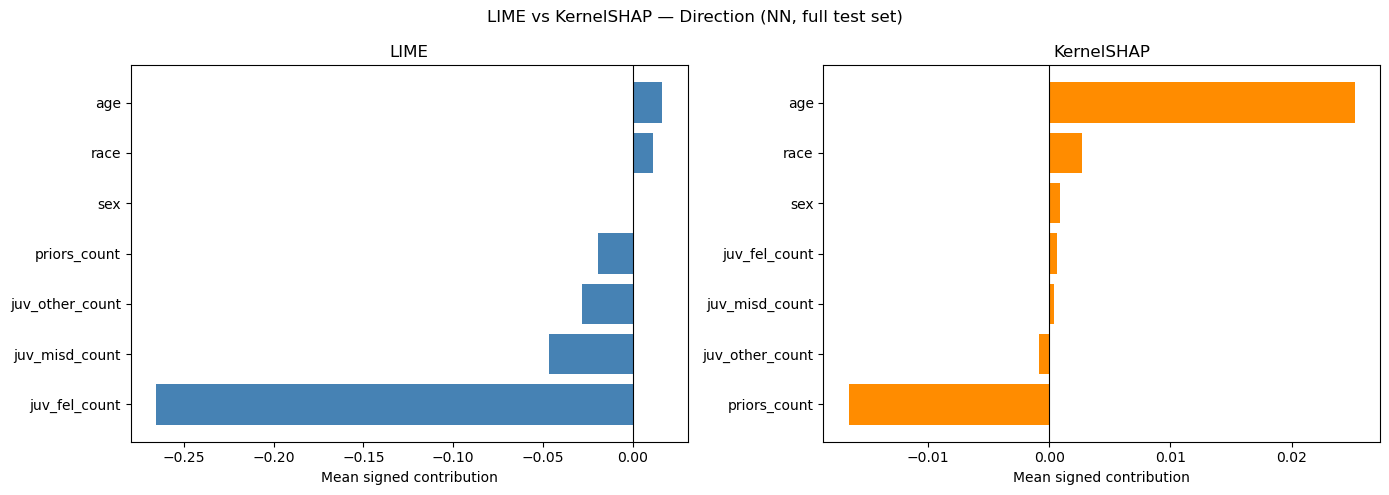

In [20]:
lime_signed_nn = np.mean(lime_explanations_nn, axis=0)
shap_signed_nn = np.mean(shap_explanations_nn, axis=0)
lime_signed_order_nn = np.argsort(lime_signed_nn)
shap_signed_order_nn = np.argsort(shap_signed_nn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(range(7), lime_signed_nn[lime_signed_order_nn], color='steelblue')
ax1.set_yticks(range(7))
ax1.set_yticklabels(np.array(features)[lime_signed_order_nn])
ax1.set_xlabel('Mean signed contribution')
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('LIME')

ax2.barh(range(7), shap_signed_nn[shap_signed_order_nn], color='darkorange')
ax2.set_yticks(range(7))
ax2.set_yticklabels(np.array(features)[shap_signed_order_nn])
ax2.set_xlabel('Mean signed contribution')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('KernelSHAP')

plt.suptitle('LIME vs KernelSHAP — Direction (NN, full test set)')
plt.tight_layout()
plt.show()

### Run LIME and KernelSHAP to full test set (with absolute to show magnitude)

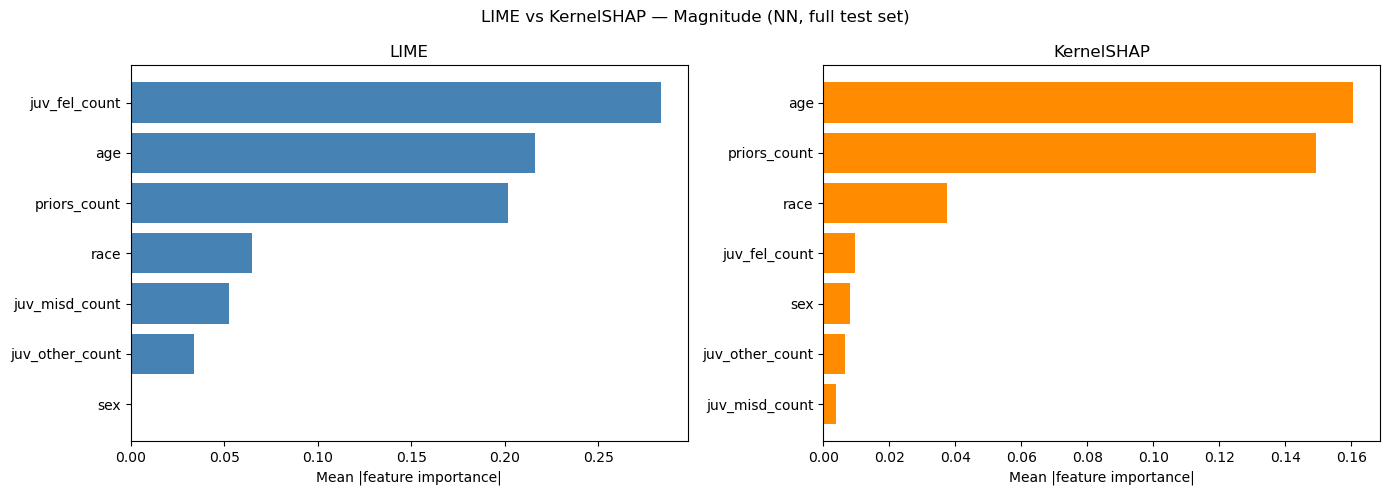

In [21]:
lime_abs_nn = np.mean(np.abs(lime_explanations_nn), axis=0)
shap_abs_nn = np.mean(np.abs(shap_explanations_nn), axis=0)
lime_abs_order_nn = np.argsort(lime_abs_nn)
shap_abs_order_nn = np.argsort(shap_abs_nn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(range(7), lime_abs_nn[lime_abs_order_nn], color='steelblue')
ax1.set_yticks(range(7))
ax1.set_yticklabels(np.array(features)[lime_abs_order_nn])
ax1.set_xlabel('Mean |feature importance|')
ax1.set_title('LIME')

ax2.barh(range(7), shap_abs_nn[shap_abs_order_nn], color='darkorange')
ax2.set_yticks(range(7))
ax2.set_yticklabels(np.array(features)[shap_abs_order_nn])
ax2.set_xlabel('Mean |feature importance|')
ax2.set_title('KernelSHAP')

plt.suptitle('LIME vs KernelSHAP — Magnitude (NN, full test set)')
plt.tight_layout()
plt.show()

# Disagreement metrics (Krishna et al. 2022)
Compute four metrics for each test sample comparing LIME and KernelSHAP explanations.

- **Feature agreement**: fraction of top-k features shared between the two explanations
- **Rank agreement**: fraction of top-k features that share the same rank
- **Sign agreement**: fraction of top-k features that share the same sign
- **Signed rank agreement**: fraction of top-k features that share the same rank and sign

In [22]:
def get_topk_indices(explanation, k):
    """Get indices of top-k features by absolute importance."""
    return np.argsort(np.abs(explanation))[::-1][:k]

def feature_agreement(exp_a, exp_b, k):
    """Fraction of top-k features shared between two explanations."""
    top_a = set(get_topk_indices(exp_a, k))
    top_b = set(get_topk_indices(exp_b, k))
    return len(top_a & top_b) / k

def rank_agreement(exp_a, exp_b, k):
    """Fraction of top-k features with same rank in both explanations."""
    top_a = get_topk_indices(exp_a, k)
    top_b = get_topk_indices(exp_b, k)
    return np.sum(top_a == top_b) / k

def sign_agreement(exp_a, exp_b, k):
    """Fraction of top-k features with same sign in both explanations."""
    top_a = get_topk_indices(exp_a, k)
    top_b = get_topk_indices(exp_b, k)
    shared = set(top_a) & set(top_b)
    if len(shared) == 0:
        return 0.0
    same_sign = sum(1 for f in shared if np.sign(exp_a[f]) == np.sign(exp_b[f]))
    return same_sign / k

def signed_rank_agreement(exp_a, exp_b, k):
    """Fraction of top-k features with same rank AND sign."""
    top_a = get_topk_indices(exp_a, k)
    top_b = get_topk_indices(exp_b, k)
    match = 0
    for i in range(k):
        if top_a[i] == top_b[i] and np.sign(exp_a[top_a[i]]) == np.sign(exp_b[top_b[i]]):
            match += 1
    return match / k

In [23]:
k = 5
metric_names = ['feature_agreement', 'rank_agreement', 'sign_agreement', 'signed_rank_agreement']
display_names = ['Feature\nAgreement', 'Rank\nAgreement', 'Sign\nAgreement', 'Signed Rank\nAgreement']

### Compute disagreement metrics (LR)

In [ ]:
metrics_lr = {
    'feature_agreement': [],
    'rank_agreement': [],
    'sign_agreement': [],
    'signed_rank_agreement': []
}

for i in range(n_test):
    lime_exp = lime_explanations[i]
    shap_exp = shap_explanations[i]

    metrics_lr['feature_agreement'].append(feature_agreement(lime_exp, shap_exp, k))
    metrics_lr['rank_agreement'].append(rank_agreement(lime_exp, shap_exp, k))
    metrics_lr['sign_agreement'].append(sign_agreement(lime_exp, shap_exp, k))
    metrics_lr['signed_rank_agreement'].append(signed_rank_agreement(lime_exp, shap_exp, k))

for key in metric_names:
    metrics_lr[key] = np.array(metrics_lr[key])

### Compute disagreement metrics (NN)

In [ ]:
metrics_nn = {
    'feature_agreement': [],
    'rank_agreement': [],
    'sign_agreement': [],
    'signed_rank_agreement': []
}

for i in range(n_test):
    lime_exp = lime_explanations_nn[i]
    shap_exp = shap_explanations_nn[i]

    metrics_nn['feature_agreement'].append(feature_agreement(lime_exp, shap_exp, k))
    metrics_nn['rank_agreement'].append(rank_agreement(lime_exp, shap_exp, k))
    metrics_nn['sign_agreement'].append(sign_agreement(lime_exp, shap_exp, k))
    metrics_nn['signed_rank_agreement'].append(signed_rank_agreement(lime_exp, shap_exp, k))

for key in metric_names:
    metrics_nn[key] = np.array(metrics_nn[key])

# Race Split

In [26]:
race_test = X_test['race'].values
black_mask = race_test == 0
white_mask = race_test == 2

### Disagreement metric (LR)

In [27]:
print(f"\n{'Metric':<25} {'African-American':>18} {'Caucasian':>12} {'Difference':>12}")
print("-" * 70)

for key in metric_names:
    black_mean = metrics_lr[key][black_mask].mean()
    white_mean = metrics_lr[key][white_mask].mean()
    diff = black_mean - white_mean
    print(f"{key:<25} {black_mean:>18.4f} {white_mean:>12.4f} {diff:>12.4f}")


Metric                      African-American    Caucasian   Difference
----------------------------------------------------------------------
feature_agreement                     0.6622       0.7110      -0.0488
rank_agreement                        0.2101       0.2374      -0.0273
sign_agreement                        0.6567       0.6996      -0.0429
signed_rank_agreement                 0.2101       0.2357      -0.0256


### Statistical test (Mann-Whitney U) of disagreement metrics (LR)

In [28]:
print(f"\n{'Metric':<25} {'U-statistic':>12} {'p-value':>12} {'Significant?':>14}")
print("-" * 65)

for key in metric_names:
    black_vals = metrics_lr[key][black_mask]
    white_vals = metrics_lr[key][white_mask]
    u_stat, p_val = mannwhitneyu(black_vals, white_vals, alternative='two-sided')
    sig = "Yes (p<0.05)" if p_val < 0.05 else "No"
    print(f"{key:<25} {u_stat:>12.1f} {p_val:>12.4f} {sig:>14}")


Metric                     U-statistic      p-value   Significant?
-----------------------------------------------------------------
feature_agreement             104866.0       0.0000   Yes (p<0.05)
rank_agreement                125621.0       0.0033   Yes (p<0.05)
sign_agreement                108579.5       0.0000   Yes (p<0.05)
signed_rank_agreement         126496.0       0.0059   Yes (p<0.05)


### Disagreement metric (NN)

In [29]:
print(f"\n{'Metric':<25} {'African-American':>18} {'Caucasian':>12} {'Difference':>12}")
print("-" * 70)

for key in metric_names:
    black_mean = metrics_nn[key][black_mask].mean()
    white_mean = metrics_nn[key][white_mask].mean()
    diff = black_mean - white_mean
    print(f"{key:<25} {black_mean:>18.4f} {white_mean:>12.4f} {diff:>12.4f}")


Metric                      African-American    Caucasian   Difference
----------------------------------------------------------------------
feature_agreement                     0.7225       0.7181       0.0044
rank_agreement                        0.2199       0.1621       0.0578
sign_agreement                        0.7130       0.7132      -0.0002
signed_rank_agreement                 0.2169       0.1604       0.0566


### Statistical test (Mann-Whitney U) of disagreement metrics (NN)

In [30]:
print(f"\n{'Metric':<25} {'U-statistic':>12} {'p-value':>12} {'Significant?':>14}")
print("-" * 65)

for key in metric_names:
    black_vals = metrics_nn[key][black_mask]
    white_vals = metrics_nn[key][white_mask]
    u_stat, p_val = mannwhitneyu(black_vals, white_vals, alternative='two-sided')
    sig = "Yes (p<0.05)" if p_val < 0.05 else "No"
    print(f"{key:<25} {u_stat:>12.1f} {p_val:>12.4f} {sig:>14}")


Metric                     U-statistic      p-value   Significant?
-----------------------------------------------------------------
feature_agreement             141721.0       0.5856             No
rank_agreement                164438.0       0.0000   Yes (p<0.05)
sign_agreement                139290.5       0.9840             No
signed_rank_agreement         164037.0       0.0000   Yes (p<0.05)


### Final comparison (Race) — LR vs NN

In [31]:
print(f"\n{'':30} {'Logistic Regression':>15} {'Neural Network':>18}")
print(f"{'Metric':<25} {'Black':>10} {'White':>10} {'Black':>10} {'White':>10}")
print("-" * 75)
for key in metric_names:
    lr_b = metrics_lr[key][black_mask].mean()
    lr_w = metrics_lr[key][white_mask].mean()
    nn_b = metrics_nn[key][black_mask].mean()
    nn_w = metrics_nn[key][white_mask].mean()
    print(f"{key:<25} {lr_b:>10.4f} {lr_w:>10.4f} {nn_b:>10.4f} {nn_w:>10.4f}")

print(f"\n{'Metric':<25} {'LR p-value':>12} {'LR sig?':>10} {'NN p-value':>12} {'NN sig?':>10}")
print("-" * 75)
for key in metric_names:
    _, p_lr = mannwhitneyu(metrics_lr[key][black_mask], metrics_lr[key][white_mask], alternative='two-sided')
    _, p_nn = mannwhitneyu(metrics_nn[key][black_mask], metrics_nn[key][white_mask], alternative='two-sided')
    sig_lr = "Yes" if p_lr < 0.05 else "No"
    sig_nn = "Yes" if p_nn < 0.05 else "No"
    print(f"{key:<25} {p_lr:>12.4f} {sig_lr:>10} {p_nn:>12.4f} {sig_nn:>10}")


                               Logistic Regression     Neural Network
Metric                         Black      White      Black      White
---------------------------------------------------------------------------
feature_agreement             0.6622     0.7110     0.7225     0.7181
rank_agreement                0.2101     0.2374     0.2199     0.1621
sign_agreement                0.6567     0.6996     0.7130     0.7132
signed_rank_agreement         0.2101     0.2357     0.2169     0.1604

Metric                      LR p-value    LR sig?   NN p-value    NN sig?
---------------------------------------------------------------------------
feature_agreement               0.0000        Yes       0.5856         No
rank_agreement                  0.0033        Yes       0.0000        Yes
sign_agreement                  0.0000        Yes       0.9840         No
signed_rank_agreement           0.0059        Yes       0.0000        Yes


### Box plot

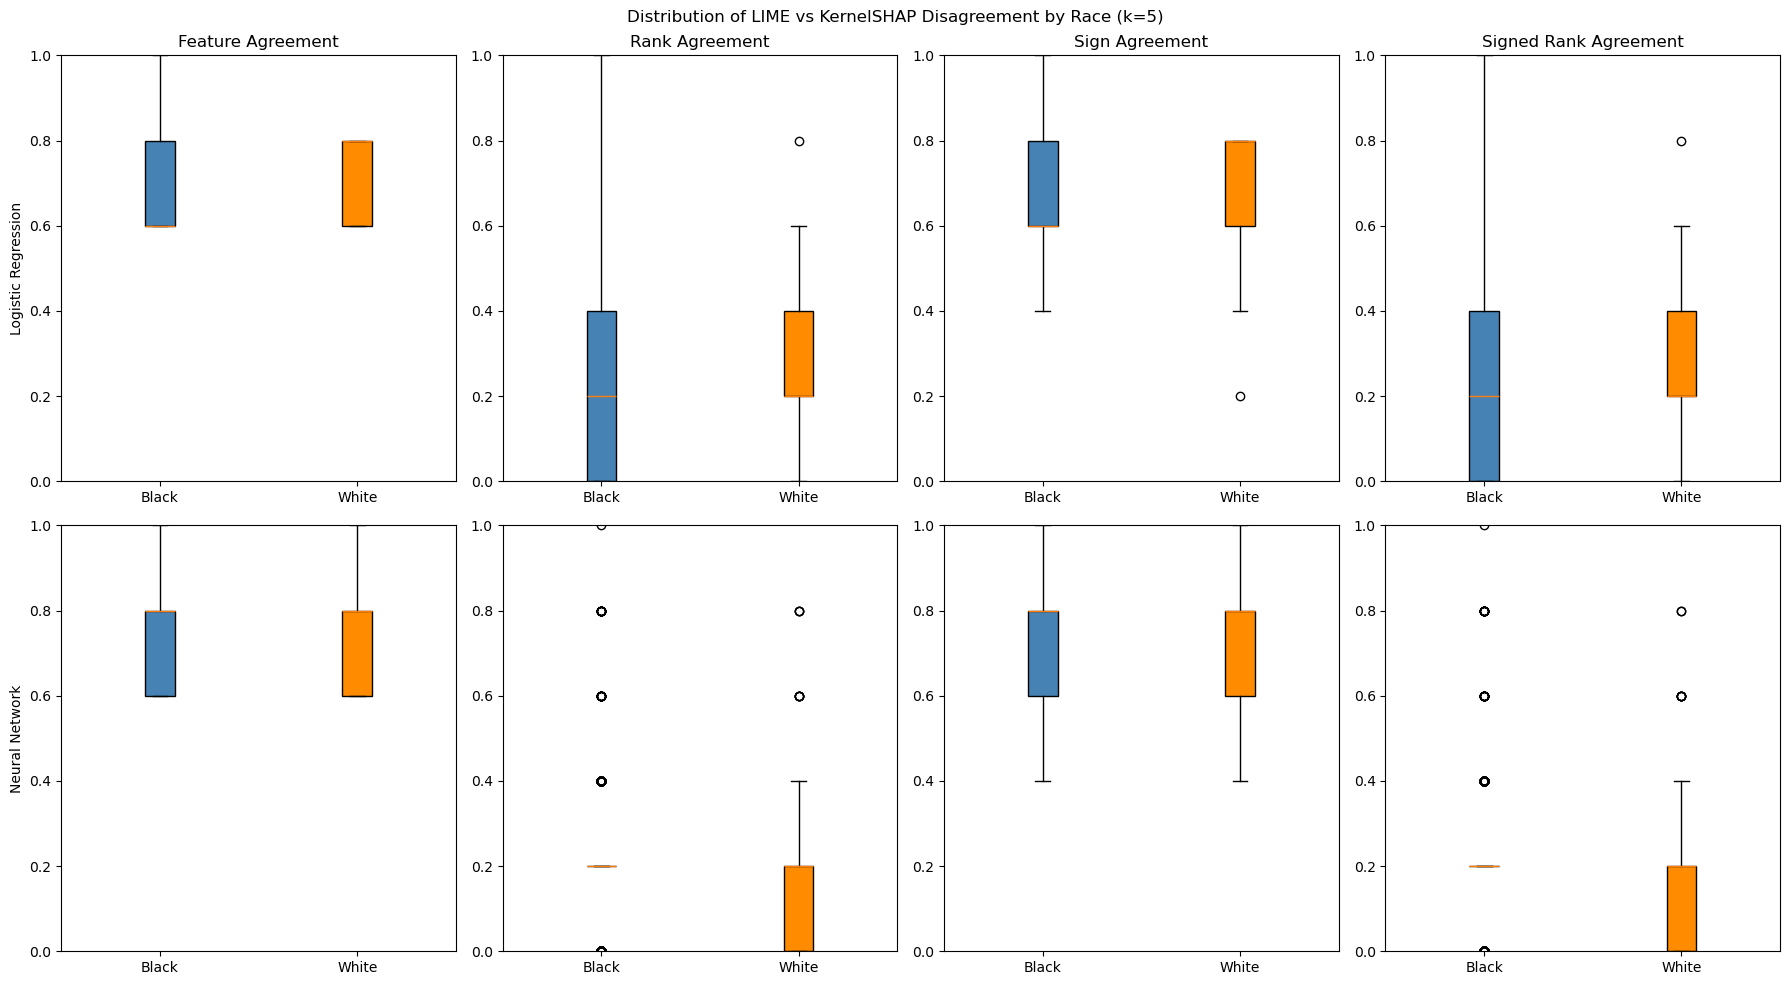

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for i, m in enumerate(metric_names):
    data_lr = [metrics_lr[m][black_mask], metrics_lr[m][white_mask]]
    bp1 = axes[0, i].boxplot(data_lr, tick_labels=['Black', 'White'], patch_artist=True)
    bp1['boxes'][0].set_facecolor('steelblue')
    bp1['boxes'][1].set_facecolor('darkorange')
    axes[0, i].set_title(display_names[i].replace('\n', ' '))
    axes[0, i].set_ylim(0, 1)
    if i == 0:
        axes[0, i].set_ylabel('Logistic Regression')
    data_nn = [metrics_nn[m][black_mask], metrics_nn[m][white_mask]]
    bp2 = axes[1, i].boxplot(data_nn, tick_labels=['Black', 'White'], patch_artist=True)
    bp2['boxes'][0].set_facecolor('steelblue')
    bp2['boxes'][1].set_facecolor('darkorange')
    axes[1, i].set_ylim(0, 1)
    if i == 0:
        axes[1, i].set_ylabel('Neural Network')

plt.suptitle('Distribution of LIME vs KernelSHAP Disagreement by Race (k=5)')
plt.tight_layout()
plt.show()

### Heatmap

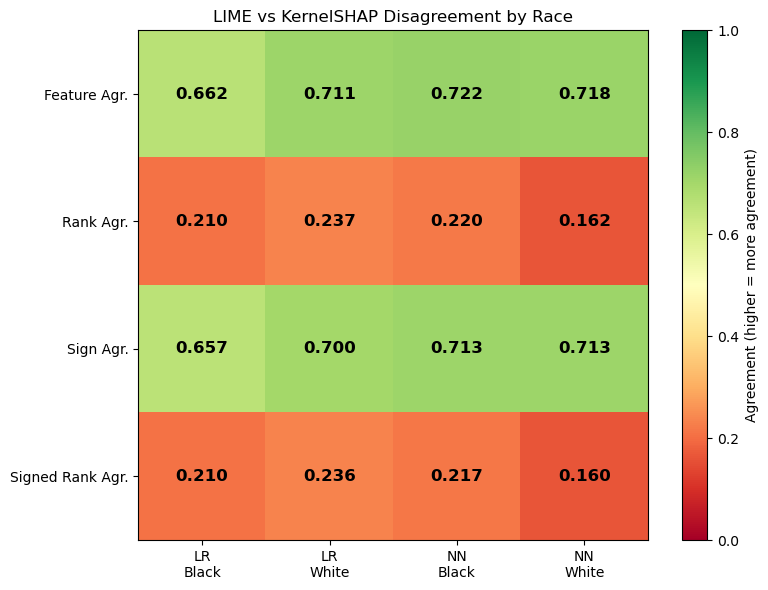

In [33]:
labels_row = ['Feature Agr.', 'Rank Agr.', 'Sign Agr.', 'Signed Rank Agr.']
labels_col = ['LR\nBlack', 'LR\nWhite', 'NN\nBlack', 'NN\nWhite']

data = np.zeros((4, 4))
for i, m in enumerate(metric_names):
    data[i, 0] = metrics_lr[m][black_mask].mean()
    data[i, 1] = metrics_lr[m][white_mask].mean()
    data[i, 2] = metrics_nn[m][black_mask].mean()
    data[i, 3] = metrics_nn[m][white_mask].mean()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(data, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(4))
ax.set_xticklabels(labels_col)
ax.set_yticks(range(4))
ax.set_yticklabels(labels_row)

for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{data[i, j]:.3f}', ha='center', va='center',
                color='black', fontsize=12, fontweight='bold')

plt.colorbar(im, label='Agreement (higher = more agreement)')
plt.title('LIME vs KernelSHAP Disagreement by Race')
plt.tight_layout()
plt.show()

---
---
---

# Gender Split

In [34]:
sex_test = X_test['sex'].values
female_mask = sex_test == 0
male_mask = sex_test == 1

### Disagreement metrics (LR)

In [35]:
print(f"\n{'Metric':<25} {'Female':>12} {'Male':>12} {'Difference':>12}")
print("-" * 65)

for key in metric_names:
    f_mean = metrics_lr[key][female_mask].mean()
    m_mean = metrics_lr[key][male_mask].mean()
    diff = f_mean - m_mean
    print(f"{key:<25} {f_mean:>12.4f} {m_mean:>12.4f} {diff:>12.4f}")


Metric                          Female         Male   Difference
-----------------------------------------------------------------
feature_agreement               0.6091       0.7113      -0.1022
rank_agreement                  0.2519       0.2129       0.0389
sign_agreement                  0.5984       0.7046      -0.1063
signed_rank_agreement           0.2486       0.2129       0.0357


### Statistical test (Mann-Whitney U) of disagreement metrics (LR)

In [36]:
print(f"\n{'Metric':<25} {'U-statistic':>12} {'p-value':>12} {'Significant?':>14}")
print("-" * 65)

for key in metric_names:
    female_vals = metrics_lr[key][female_mask]
    male_vals = metrics_lr[key][male_mask]
    u_stat, p_val = mannwhitneyu(female_vals, male_vals, alternative='two-sided')
    sig = "Yes (p<0.05)" if p_val < 0.05 else "No"
    print(f"{key:<25} {u_stat:>12.1f} {p_val:>12.4f} {sig:>14}")


Metric                     U-statistic      p-value   Significant?
-----------------------------------------------------------------
feature_agreement              59496.0       0.0000   Yes (p<0.05)
rank_agreement                135492.5       0.0014   Yes (p<0.05)
sign_agreement                 59536.5       0.0000   Yes (p<0.05)
signed_rank_agreement         134095.5       0.0038   Yes (p<0.05)


### Disagreement metrics (NN)

In [37]:
print(f"\n{'Metric':<25} {'Female':>12} {'Male':>12} {'Difference':>12}")
print("-" * 65)

for key in metric_names:
    f_mean = metrics_nn[key][female_mask].mean()
    m_mean = metrics_nn[key][male_mask].mean()
    diff = f_mean - m_mean
    print(f"{key:<25} {f_mean:>12.4f} {m_mean:>12.4f} {diff:>12.4f}")


Metric                          Female         Male   Difference
-----------------------------------------------------------------
feature_agreement               0.7300       0.7278       0.0022
rank_agreement                  0.1770       0.1980      -0.0210
sign_agreement                  0.7210       0.7204       0.0006
signed_rank_agreement           0.1770       0.1950      -0.0180


### Statistical test (Mann-Whitney U) of disagreement metrics (NN)

In [38]:
print(f"\n{'Metric':<25} {'U-statistic':>12} {'p-value':>12} {'Significant?':>14}")
print("-" * 65)

for key in metric_names:
    female_vals = metrics_nn[key][female_mask]
    male_vals = metrics_nn[key][male_mask]
    u_stat, p_val = mannwhitneyu(female_vals, male_vals, alternative='two-sided')
    sig = "Yes (p<0.05)" if p_val < 0.05 else "No"
    print(f"{key:<25} {u_stat:>12.1f} {p_val:>12.4f} {sig:>14}")


Metric                     U-statistic      p-value   Significant?
-----------------------------------------------------------------
feature_agreement             122970.0       0.5663             No
rank_agreement                113152.5       0.1004             No
sign_agreement                122400.0       0.6642             No
signed_rank_agreement         114197.0       0.1566             No


### Final comparison (Gender) — LR vs NN

In [39]:
print(f"\n{'':30} {'Logistic Regression':>15} {'Neural Network':>18}")
print(f"{'Metric':<25} {'Female':>10} {'Male':>10} {'Female':>10} {'Male':>10}")
print("-" * 75)
for key in metric_names:
    lr_f = metrics_lr[key][female_mask].mean()
    lr_m = metrics_lr[key][male_mask].mean()
    nn_f = metrics_nn[key][female_mask].mean()
    nn_m = metrics_nn[key][male_mask].mean()
    print(f"{key:<25} {lr_f:>10.4f} {lr_m:>10.4f} {nn_f:>10.4f} {nn_m:>10.4f}")

print(f"\n{'Metric':<25} {'LR p-value':>12} {'LR sig?':>10} {'NN p-value':>12} {'NN sig?':>10}")
print("-" * 75)
for key in metric_names:
    _, p_lr = mannwhitneyu(metrics_lr[key][female_mask], metrics_lr[key][male_mask], alternative='two-sided')
    _, p_nn = mannwhitneyu(metrics_nn[key][female_mask], metrics_nn[key][male_mask], alternative='two-sided')
    sig_lr = "Yes" if p_lr < 0.05 else "No"
    sig_nn = "Yes" if p_nn < 0.05 else "No"
    print(f"{key:<25} {p_lr:>12.4f} {sig_lr:>10} {p_nn:>12.4f} {sig_nn:>10}")


                               Logistic Regression     Neural Network
Metric                        Female       Male     Female       Male
---------------------------------------------------------------------------
feature_agreement             0.6091     0.7113     0.7300     0.7278
rank_agreement                0.2519     0.2129     0.1770     0.1980
sign_agreement                0.5984     0.7046     0.7210     0.7204
signed_rank_agreement         0.2486     0.2129     0.1770     0.1950

Metric                      LR p-value    LR sig?   NN p-value    NN sig?
---------------------------------------------------------------------------
feature_agreement               0.0000        Yes       0.5663         No
rank_agreement                  0.0014        Yes       0.1004         No
sign_agreement                  0.0000        Yes       0.6642         No
signed_rank_agreement           0.0038        Yes       0.1566         No


### Box Plot

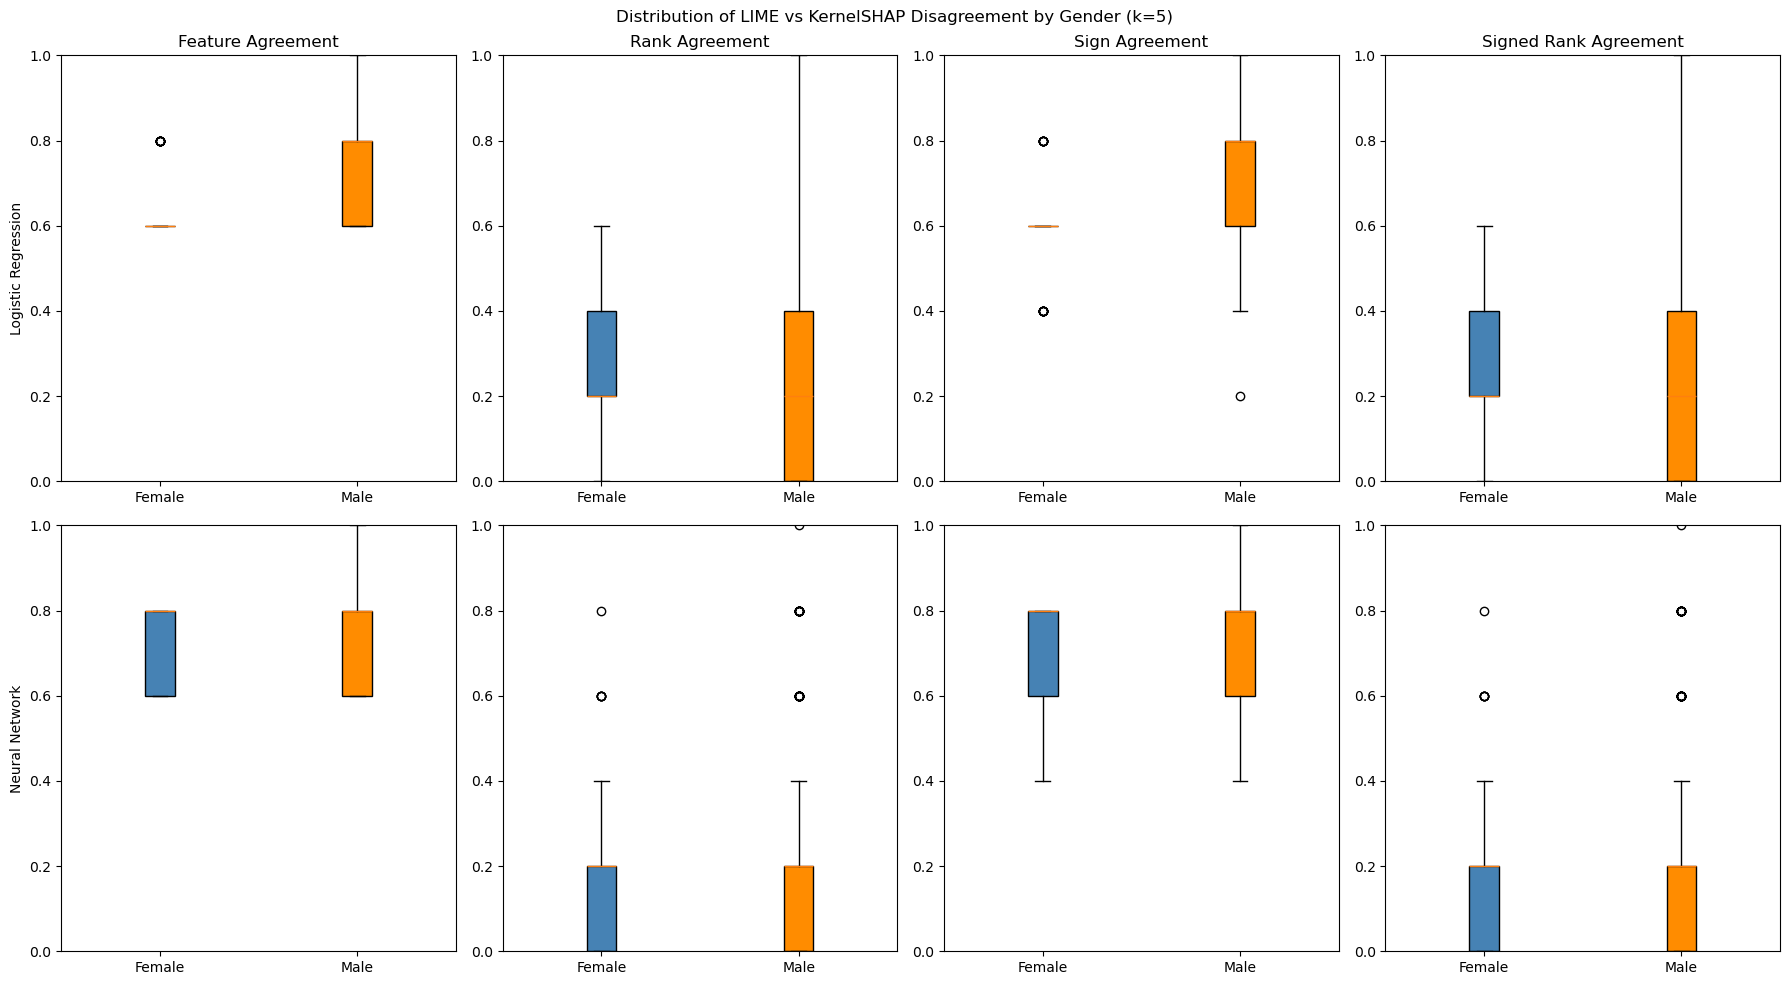

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for i, m in enumerate(metric_names):
    data_lr = [metrics_lr[m][female_mask], metrics_lr[m][male_mask]]
    bp1 = axes[0, i].boxplot(data_lr, tick_labels=['Female', 'Male'], patch_artist=True)
    bp1['boxes'][0].set_facecolor('steelblue')
    bp1['boxes'][1].set_facecolor('darkorange')
    axes[0, i].set_title(display_names[i].replace('\n', ' '))
    axes[0, i].set_ylim(0, 1)
    if i == 0:
        axes[0, i].set_ylabel('Logistic Regression')

    data_nn = [metrics_nn[m][female_mask], metrics_nn[m][male_mask]]
    bp2 = axes[1, i].boxplot(data_nn, tick_labels=['Female', 'Male'], patch_artist=True)
    bp2['boxes'][0].set_facecolor('steelblue')
    bp2['boxes'][1].set_facecolor('darkorange')
    axes[1, i].set_ylim(0, 1)
    if i == 0:
        axes[1, i].set_ylabel('Neural Network')

plt.suptitle('Distribution of LIME vs KernelSHAP Disagreement by Gender (k=5)')
plt.tight_layout()
plt.show()

### Heatmap

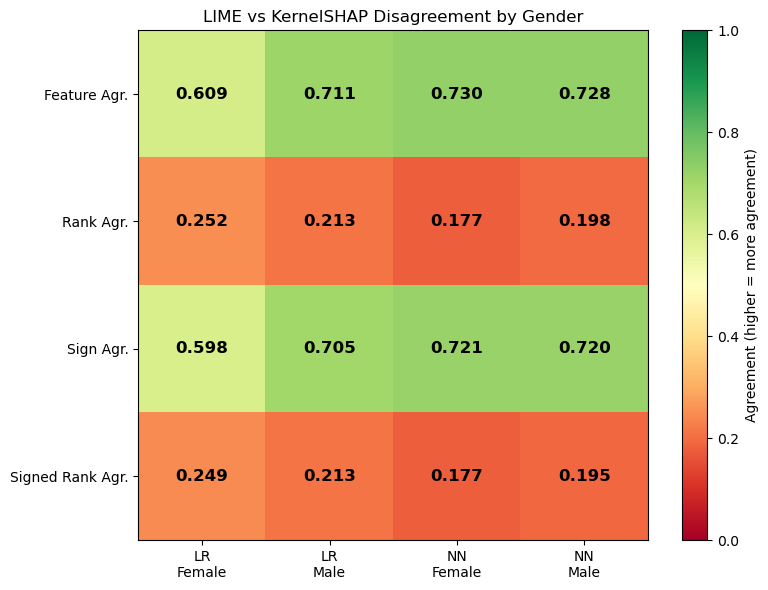

In [ ]:
labels_row = ['Feature Agr.', 'Rank Agr.', 'Sign Agr.', 'Signed Rank Agr.']
labels_col = ['LR\nFemale', 'LR\nMale', 'NN\nFemale', 'NN\nMale']
data = np.zeros((4, 4))

for i, m in enumerate(metric_names):
    data[i, 0] = metrics_lr[m][female_mask].mean()
    data[i, 1] = metrics_lr[m][male_mask].mean()
    data[i, 2] = metrics_nn[m][female_mask].mean()
    data[i, 3] = metrics_nn[m][male_mask].mean()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(data, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(4))
ax.set_xticklabels(labels_col)
ax.set_yticks(range(4))
ax.set_yticklabels(labels_row)

for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{data[i, j]:.3f}', ha='center', va='center',
                color='black', fontsize=12, fontweight='bold')

plt.colorbar(im, label='Agreement (higher = more agreement)')
plt.title('LIME vs KernelSHAP Disagreement by Gender')
plt.tight_layout()
plt.show()